In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import os

# Updated base path to match the actual Kaggle file system
base_path = '/kaggle/input/datasets/iamchaarles/banalyzer-banana-ripeness-classification-dataset/banana_data/data'

train_dir = os.path.join(base_path, 'train')
test_dir = os.path.join(base_path, 'test')

# Verify the folders exist
try:
    print(f"Training categories: {os.listdir(train_dir)}")
except FileNotFoundError:
    print("Path still not found. Check the spelling of the dataset folder.")


Training categories: ['unripe', 'overripe', 'rotten', 'ripe']


In [3]:
for folder in os.listdir(train_dir):
    path = os.path.join(train_dir, folder)
    print(f"{folder}: {len(os.listdir(path))} images")

unripe: 250 images
overripe: 250 images
rotten: 250 images
ripe: 250 images


Banana Ripeness Classifier - Training
Image Size: 640x640 | Batch Size: 4

1. Loading datasets...
Found 1000 images belonging to 4 classes.
Found 200 images belonging to 4 classes.
   Training samples: 1000
   Validation samples: 200
   Classes: {'overripe': 0, 'ripe': 1, 'rotten': 2, 'unripe': 3}

2. Building MobileNetV2 model...


/tmp/ipykernel_55/3796458543.py:68: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(
I0000 00:00:1776747336.126559      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776747336.132766      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 20, 20, 1280)   │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...


3. Training model for 20 epochs...
------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


I0000 00:00:1776747346.308225     140 service.cc:152] XLA service 0x7f7f80112640 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776747346.308279     140 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776747346.308286     140 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776747347.493010     140 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-21 04:55:54.993323: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-21 04:55:55.131126: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-21 04:55:55.954361: E external/local_xl

250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 675ms/step - accuracy: 0.5718 - loss: 1.0150
Epoch 1: val_accuracy improved from -inf to 0.77000, saving model to /kaggle/working/models/best_model.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 215s 770ms/step - accuracy: 0.5723 - loss: 1.0141 - val_accuracy: 0.7700 - val_loss: 0.6413 - learning_rate: 0.0010
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 582ms/step - accuracy: 0.8297 - loss: 0.4553
Epoch 2: val_accuracy improved from 0.77000 to 0.82000, saving model to /kaggle/working/models/best_model.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 157s 627ms/step - accuracy: 0.8297 - loss: 0.4552 - val_accuracy: 0.8200 - val_loss: 0.4631 - learning_rate: 0.0010
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 562ms/step - accuracy: 0.8705 - loss: 0.3812
Epoch 3: val_accuracy improved from 0.82000 to 0.85500, saving model to /kaggle/working/models/best_model.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 152s 609ms/step - accuracy: 0.8704 - loss: 0.3812 - val_accuracy: 0.8550 - val_loss: 0.4284 - l

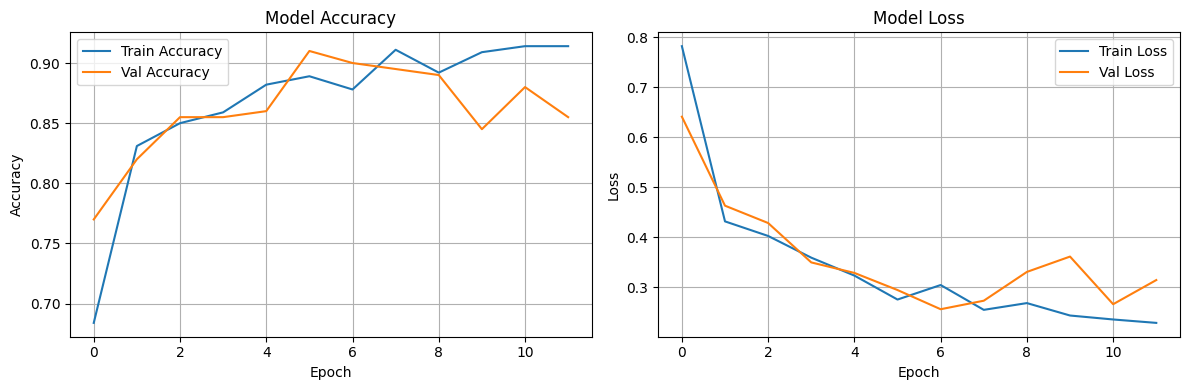


✓ Training history plot saved to /kaggle/working/models/training_history.png

Training Complete!

Models saved in: /kaggle/working/models/
- best_model.keras (best validation accuracy)
- banana_classifier_final.keras (final model)


In [4]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

# Configuration
IMG_SIZE = 640
BATCH_SIZE = 4 
EPOCHS = 20
NUM_CLASSES = 4
CLASS_NAMES = ['overripe', 'ripe', 'rotten', 'unripe']

# Paths
TRAIN_DIR = train_dir
VAL_DIR = test_dir
MODEL_DIR = '/kaggle/working/models'

# Create models directory if it doesn't exist
os.makedirs(MODEL_DIR, exist_ok=True)

def create_datasets():
    """Load and prepare training and validation datasets using ImageDataGenerator (TF 2.20 compatible)"""
    
    # Data augmentation for training - SAME AS YOUR ORIGINAL
    train_datagen = keras.preprocessing.image.ImageDataGenerator(
        rescale=1./255,
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        horizontal_flip=True,
        zoom_range=0.2,
        brightness_range=[0.8, 1.2],
        fill_mode='nearest'
    )
    
    # Only rescaling for validation - SAME AS YOUR ORIGINAL
    val_datagen = keras.preprocessing.image.ImageDataGenerator(
        rescale=1./255
    )
    
    train_dataset = train_datagen.flow_from_directory(
        TRAIN_DIR,
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=True
    )
    
    val_dataset = val_datagen.flow_from_directory(
        VAL_DIR,
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False
    )
    
    return train_dataset, val_dataset

def build_model():
    """Build MobileNetV2-based transfer learning model - SAME AS YOUR ORIGINAL"""
    
    # Load pre-trained MobileNetV2 (without top classification layer)
    base_model = MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )
    
    # Freeze base model layers
    base_model.trainable = False
    
    # Build complete model - SAME AS YOUR ORIGINAL
    model = keras.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])
    
    # Compile model - SAME AS YOUR ORIGINAL
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

def plot_training_history(history):
    """Plot training and validation metrics"""
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Plot accuracy
    ax1.plot(history.history['accuracy'], label='Train Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
    ax1.set_title('Model Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True)
    
    # Plot loss
    ax2.plot(history.history['loss'], label='Train Loss')
    ax2.plot(history.history['val_loss'], label='Val Loss')
    ax2.set_title('Model Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_DIR, 'training_history.png'))
    plt.show()
    
    print(f"\n✓ Training history plot saved to {MODEL_DIR}/training_history.png")

def main():
    """Main training pipeline"""
    
    print("="*60)
    print("Banana Ripeness Classifier - Training")
    print(f"Image Size: {IMG_SIZE}x{IMG_SIZE} | Batch Size: {BATCH_SIZE}")
    print("="*60)
    
    # Load datasets
    print("\n1. Loading datasets...")
    train_ds, val_ds = create_datasets()
    
    print(f"   Training samples: {train_ds.samples}")
    print(f"   Validation samples: {val_ds.samples}")
    print(f"   Classes: {train_ds.class_indices}")
    
    # Build model
    print("\n2. Building MobileNetV2 model...")
    model = build_model()
    model.summary()
    
    # Setup callbacks
    callbacks = [
        keras.callbacks.ModelCheckpoint(
            filepath=os.path.join(MODEL_DIR, 'best_model.keras'),
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        ),
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            verbose=1
        )
    ]
    
    # Train model
    print(f"\n3. Training model for {EPOCHS} epochs...")
    print("-"*60)
    
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=1
    )
    
    # Evaluate model
    print("\n4. Evaluating model...")
    val_loss, val_accuracy = model.evaluate(val_ds)
    print(f"\n   Final Validation Accuracy: {val_accuracy*100:.2f}%")
    print(f"   Final Validation Loss: {val_loss:.4f}")
    
    # Save final model
    final_model_path = os.path.join(MODEL_DIR, 'banana_classifier_final.keras')
    model.save(final_model_path)
    print(f"\n✓ Final model saved to {final_model_path}")
    
    # Plot training history
    print("\n5. Generating training plots...")
    plot_training_history(history)
    
    print("\n" + "="*60)
    print("Training Complete!")
    print("="*60)
    print(f"\nModels saved in: {MODEL_DIR}/")
    print("- best_model.keras (best validation accuracy)")
    print("- banana_classifier_final.keras (final model)")

if __name__ == "__main__":
    main()

In [5]:
import os
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

# 1. Load your best model
model = load_model('/kaggle/input/datasets/jeremykulisek/random/best_model.keras')

# 2. Set the test directory
TEST_BASE_DIR = '/kaggle/input/datasets/iamchaarles/banalyzer-banana-ripeness-classification-dataset/banana_data/data/test'
CLASS_NAMES = ['overripe', 'ripe', 'rotten', 'unripe']

def evaluate_folder(folder_name):
    folder_path = os.path.join(TEST_BASE_DIR, folder_name)
    images = os.listdir(folder_path)
    correct = 0
    total = len(images)
    
    for img_name in images:
        img_path = os.path.join(folder_path, img_name)
        
        # Preprocessing to match training (224x224 and rescale)
        img = image.load_img(img_path, target_size=(640, 640))
        img_array = image.img_to_array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0)
        
        prediction = model.predict(img_array, verbose=0)
        pred_label = CLASS_NAMES[np.argmax(prediction)]
        
        if pred_label == folder_name:
            correct += 1
            
    accuracy = (correct / total) * 100
    print(f"Category: {folder_name:10} | Accuracy: {accuracy:.2f}% ({correct}/{total})")

# Run evaluation for all categories
print("--- Test Set Performance ---")
for category in CLASS_NAMES:
    evaluate_folder(category)

--- Test Set Performance ---
Category: overripe   | Accuracy: 88.00% (44/50)
Category: ripe       | Accuracy: 86.00% (43/50)
Category: rotten     | Accuracy: 100.00% (50/50)
Category: unripe     | Accuracy: 100.00% (50/50)


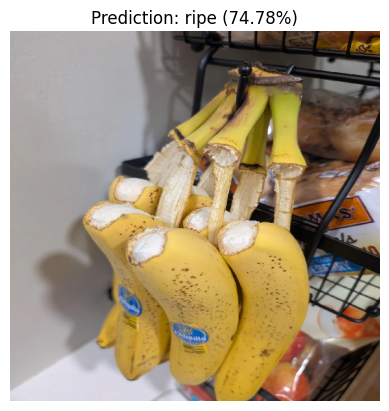

The model is 74.78% sure this banana is ripe.


In [12]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# 1. Path to your random test image
random_img_path = '/kaggle/input/datasets/jeremykulisek/random/unfilterd/banana8.JPG'

# 2. Preprocess the image (must match training: 640x640 and rescale)
img = image.load_img(random_img_path, target_size=(640, 640))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# 3. Get the prediction
prediction = model.predict(img_array, verbose=0)
class_idx = np.argmax(prediction)
confidence = prediction[0][class_idx]
label = CLASS_NAMES[class_idx]

# 4. Display the result
plt.imshow(img)
plt.title(f"Prediction: {label} ({confidence*100:.2f}%)")
plt.axis('off')
plt.show()

print(f"The model is {confidence*100:.2f}% sure this banana is {label}.")

In [ ]:
import os
import shutil
import numpy as np
from tensorflow.keras.preprocessing import image

# 1. Define Paths
INPUT_DIR = '/kaggle/input/datasets/jeremykulisek/random/unfilterd'
OUTPUT_BASE = '/kaggle/working/sorted_bananas'
CLASS_NAMES = ['overripe', 'ripe', 'rotten', 'unripe']

# 2. Create the 4 output directories
for class_name in CLASS_NAMES:
    os.makedirs(os.path.join(OUTPUT_BASE, class_name), exist_ok=True)

print("--- Starting Automated Sorting ---")

# 3. Loop through all images in the unfiltered folder
for filename in os.listdir(INPUT_DIR):
    if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
        file_path = os.path.join(INPUT_DIR, filename)
        
        # Preprocess
        img = image.load_img(file_path, target_size=(640, 640))
        img_array = image.img_to_array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0)
        
        # Predict
        prediction = model.predict(img_array, verbose=0)
        class_idx = np.argmax(prediction)
        predicted_class = CLASS_NAMES[class_idx]
        confidence = prediction[0][class_idx]
        
        # Define destination and copy file
        dest_path = os.path.join(OUTPUT_BASE, predicted_class, filename)
        shutil.copy(file_path, dest_path)
        
        print(f"Sorted {filename} -> {predicted_class} ({confidence*100:.2f}%)")

print("\n--- Sorting Complete! ---")
print(f"Check the folders in: {OUTPUT_BASE}")

In [1]:
import os
import numpy as np
import shutil
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

# 1. Load your best model
model = load_model('/kaggle/input/datasets/jeremykulisek/random/best_model.keras')

# 2. Define Paths
INPUT_DIR = '/kaggle/input/datasets/jeremykulisek/random/unfilterd'
OUTPUT_BASE = '/kaggle/working/sorted_bananas'
CLASS_NAMES = ['overripe', 'ripe', 'rotten', 'unripe']

# 3. Create the 4 output directories
for class_name in CLASS_NAMES:
    os.makedirs(os.path.join(OUTPUT_BASE, class_name), exist_ok=True)

print("--- Starting Automated Sorting ---")

# 4. Loop through all images in the unfiltered folder
for filename in os.listdir(INPUT_DIR):
    if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
        file_path = os.path.join(INPUT_DIR, filename)
        
        # Preprocess
        img = image.load_img(file_path, target_size=(640, 640))
        img_array = image.img_to_array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0)
        
        # Predict
        prediction = model.predict(img_array, verbose=0)
        class_idx = np.argmax(prediction)
        predicted_class = CLASS_NAMES[class_idx]
        confidence = prediction[0][class_idx]
        
        # Define destination and copy file
        dest_path = os.path.join(OUTPUT_BASE, predicted_class, filename)
        shutil.copy(file_path, dest_path)
        
        print(f"Sorted {filename} -> {predicted_class} ({confidence*100:.2f}%)")

print("\n--- Sorting Complete! ---")
print(f"Check the folders in: {OUTPUT_BASE}")

2026-04-20 21:33:04.414078: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776720784.664844      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776720784.743045      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776720785.415549      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776720785.415589      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776720785.415592      55 computation_placer.cc:177] computation placer alr

--- Starting Automated Sorting ---
Sorted banana4.jpg -> overripe (94.02%)
Sorted banana9.JPG -> unripe (99.97%)
Sorted banana10.JPG -> unripe (86.90%)
Sorted banana6.jpg -> overripe (40.94%)
Sorted banana14.JPG -> unripe (78.15%)
Sorted banana3.jpg -> unripe (99.50%)
Sorted banana7.JPG -> unripe (94.18%)
Sorted banana13.JPG -> overripe (96.38%)
Sorted banana1.jpg -> overripe (93.00%)
Sorted banana5.jpg -> rotten (93.07%)
Sorted banana12.JPG -> unripe (92.84%)
Sorted banana11.JPG -> unripe (98.90%)
Sorted banana2.jpg -> ripe (82.11%)
Sorted banana8.JPG -> ripe (74.78%)

--- Sorting Complete! ---
Check the folders in: /kaggle/working/sorted_bananas


In [3]:
import tensorflow as tf
import keras

# Use __version__ to get the string representation
print(f"TensorFlow Version: {tf.__version__}")
print(f"Keras Version: {keras.__version__}")

TensorFlow Version: 2.19.0
Keras Version: 3.10.0
